In [ ]:
import zipfile
with zipfile.ZipFile('train.csv.zip', 'r') as z:
  z.extractall()

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9800, 18)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.87
Furniture          728658.58
Office Supplies    705422.33
Name: Sales, dtype: float64


In [ ]:
state_sales = df.groupby('State')['Sales'].sum().round(2).sort_values(ascending=False).head(10)
print(state_sales)

State
California      446306.46
New York        306361.15
Texas           168572.53
Washington      135206.85
Pennsylvania    116276.65
Florida          88436.53
Illinois         79236.52
Michigan         76136.07
Ohio             75130.35
Virginia         70636.72
Name: Sales, dtype: float64


In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum().round(2).sort_values(ascending=False)
print(segment_sales)

Segment
Consumer       1148060.53
Corporate       688494.07
Home Office     424982.18
Name: Sales, dtype: float64


In [ ]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().round(2)
print(monthly_sales)

Year  Month
2015  1         14205.71
      2          4519.89
      3         55205.80
      4         27906.86
      5         23644.30
      6         34322.94
      7         33781.54
      8         27117.54
      9         81623.53
      10        31453.39
      11        77907.66
      12        68167.06
2016  1         18066.96
      2         11951.41
      3         32339.32
      4         34154.47
      5         29959.53
      6         23599.37
      7         28608.26
      8         36818.34
      9         63133.61
      10        31011.74
      11        75249.40
      12        74543.60
2017  1         18542.49
      2         22978.82
      3         51165.06
      4         38679.77
      5         56656.91
      6         39724.49
      7         38320.78
      8         30542.20
      9         69193.39
      10        59583.03
      11        79066.50
      12        95739.12
2018  1         43476.47
      2         19921.00
      3         58863.41
      4      

In [ ]:
product_sales = df.groupby('Product Name')['Sales'].sum().round(2).sort_values(ascending=False).head(10)
print(product_sales)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: Sales, dtype: float64


In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().round(2).sort_values(ascending=False).head(5)
print(region_sales)

Region
West       710219.68
East       669518.73
Central    492646.91
South      389151.46
Name: Sales, dtype: float64


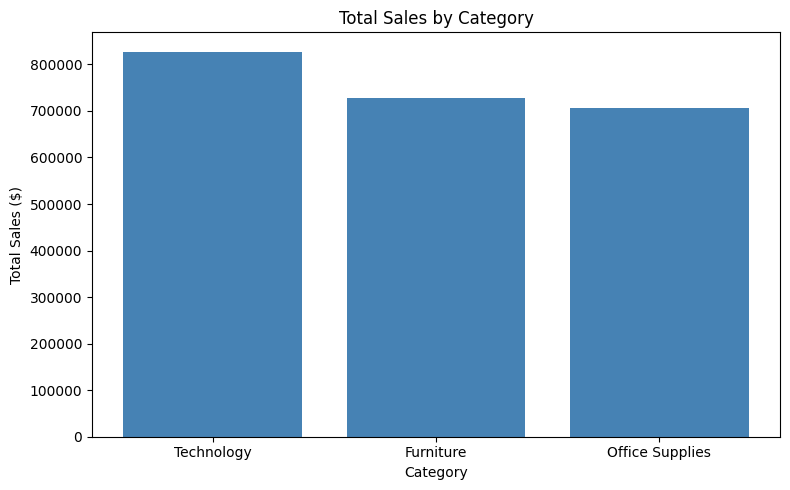

In [3]:
import matplotlib.pyplot as plt
categories = ['Technology', 'Furniture', 'Office Supplies']
sales = [827455.87, 728658.58, 705422.33]

plt.figure(figsize = (8,5))
plt.bar(categories, sales, color = 'steelblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

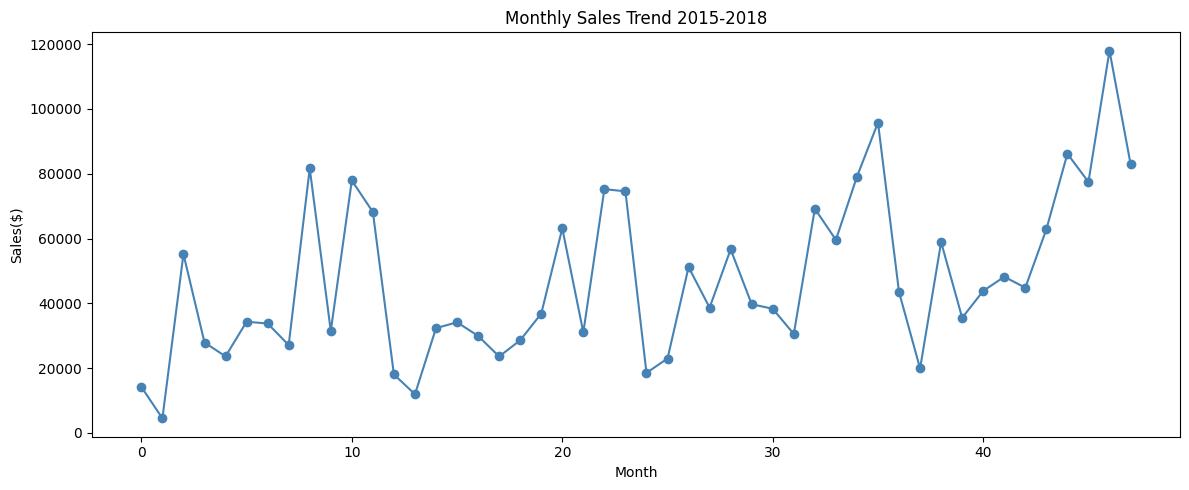

In [12]:
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
with zipfile.ZipFile('train.csv.zip', 'r') as z:
    z.extractall()


df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
plt.figure(figsize = (12, 5))
plt.plot(range(len(monthly)), monthly['Sales'], marker = 'o', color = 'steelblue')
plt.title('Monthly Sales Trend 2015-2018')
plt.xlabel('Month')
plt.ylabel('Sales($)')
plt.tight_layout()
plt.show()

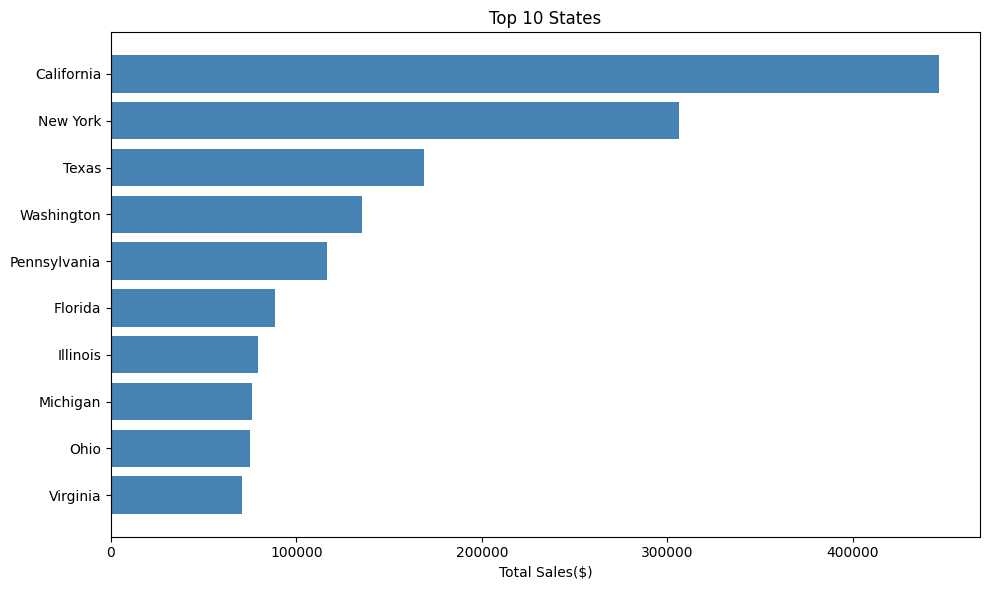

In [14]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(state_sales.index,state_sales.values, color = 'steelblue')
plt.title('Top 10 States')
plt.xlabel('Total Sales($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

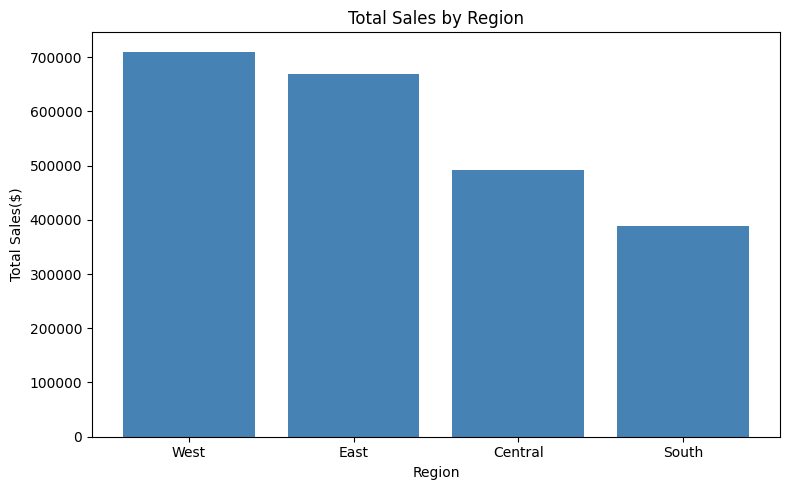

In [17]:
categories = ['West', 'East', 'Central', 'South']
sales = [710219.68,669518.73,492646.91,389151.46]

plt.figure(figsize=(8,5))
plt.bar(categories, sales, color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales($)')
plt.tight_layout()
plt.show()